<a href="https://colab.research.google.com/github/maanaav15369/ML-Projects/blob/main/Paper_leak_from_04t_026_EDA%26ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # for matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Additional settings for sns
sns.set(style='whitegrid', palette='muted', color_codes=True)

In [17]:
df = pd.read_csv('/content/paper_leaks.csv')

Data Cleaning and Exploratory Data Analysis
In this section we explore the dataset. We first inspect the data, check for missing values, and visualize some of the key numerical and categorical distributions. Our visualizations include heatmaps for correlations (using only numeric columns), pair plots, histogram distributions, pie and bar plots, and box plots. This multi-pronged approach gives us insights into the underlying patterns and relationships in the data.

DataFrame shape: (110, 18)
Columns: ['incident_id', 'date', 'era', 'exam_name', 'conducting_body', 'body_type', 'area', 'leak_status', 'action_taken', 'note', 'arrests', 'convictions', 'aspirants_affected', 'linked_deaths', 'deaths_note', 'source_name', 'source_url', 'confidence']
Missing values in each column:
incident_id             0
date                    0
era                     0
exam_name               0
conducting_body         0
body_type               0
area                    0
leak_status             0
action_taken            0
note                    0
arrests                47
convictions           100
aspirants_affected     66
linked_deaths         106
deaths_note           106
source_name             0
source_url              0
confidence              0
dtype: int64


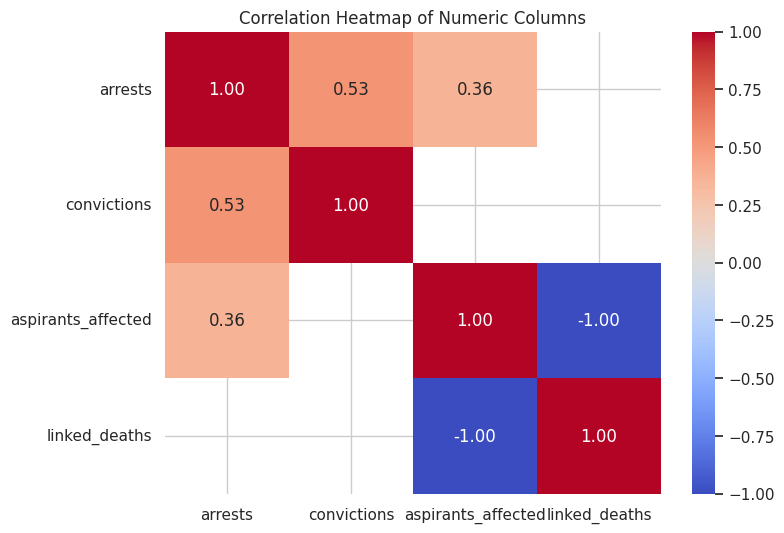

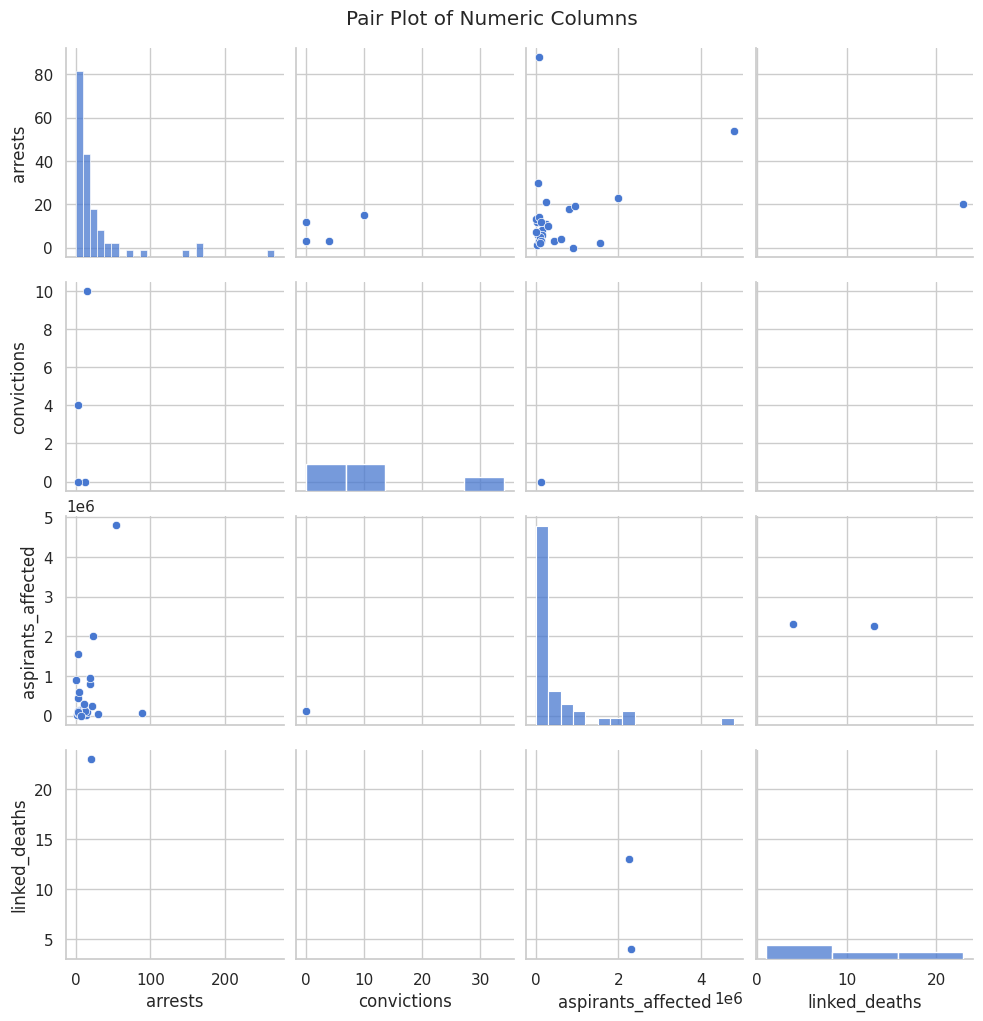

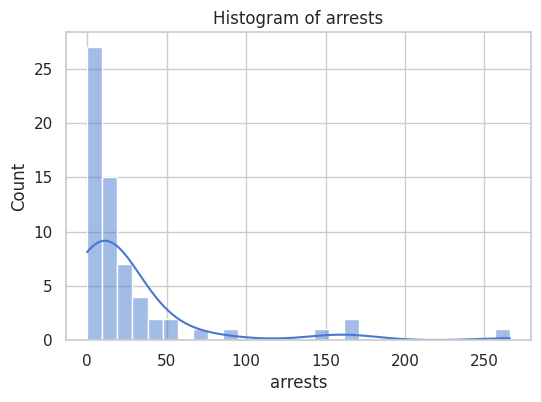

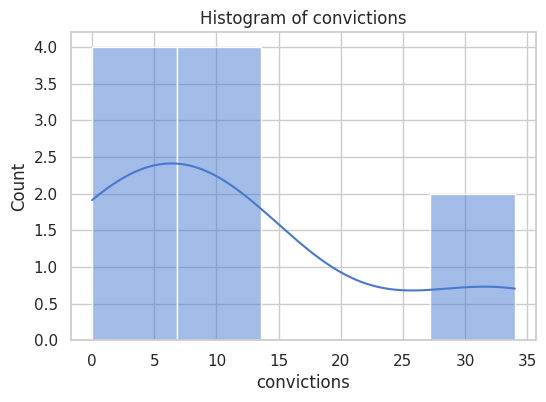

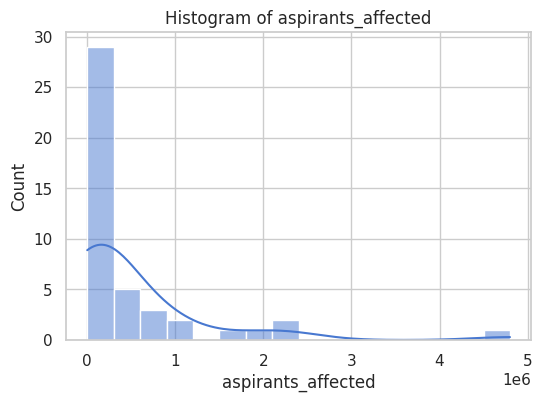

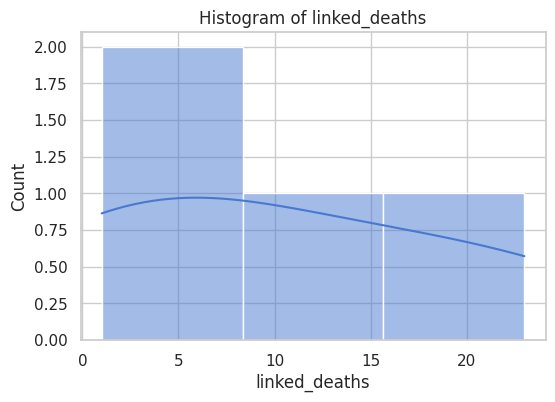

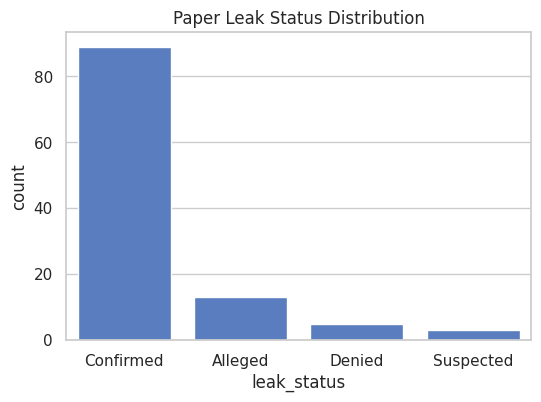

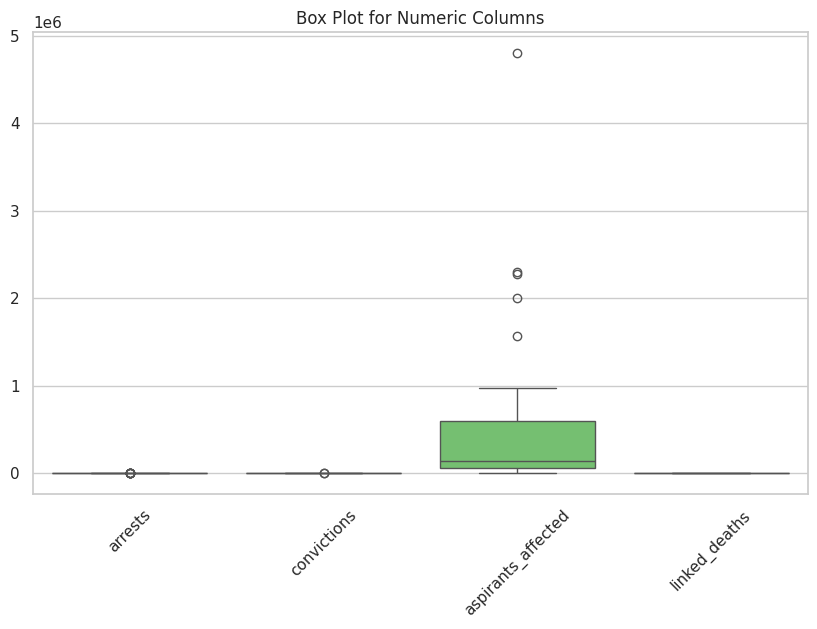

In [18]:
# Quick inspection of the data
print('DataFrame shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Missing values in each column:')
print(df.isnull().sum())

# Only consider the numeric columns for correlation and pair plots
numeric_df = df.select_dtypes(include=[np.number])

# If there are 4 or more numeric columns, produce a correlation heatmap
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Columns')
    plt.show()

# Produce a pair plot for the numeric variables
sns.pairplot(numeric_df)
plt.suptitle('Pair Plot of Numeric Columns', y=1.02)
plt.show()

# Histograms for a few numeric columns
for col in numeric_df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(numeric_df[col].dropna(), kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

# Count plot for a key categorical variable: leak_status
if 'leak_status' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='leak_status')
    plt.title('Paper Leak Status Distribution')
    plt.show()

# Box Plot for numeric columns to inspect outliers
numeric_cols = numeric_df.columns.tolist()
plt.figure(figsize=(10, 6))
sns.boxplot(data=numeric_df[numeric_cols])
plt.title('Box Plot for Numeric Columns')
plt.xticks(rotation=45)
plt.show()

#Predictive Modeling
Now we attempt to build a rudimentary predictive model. The goal is to predict whether a paper leak incident led to at least one linked death. To this end, we create a binary target variable called death_event (1 if there was at least one linked death, otherwise 0).

We will use arrests, convictions, and aspirants_affected as features. However, be mindful that our dataset might have very few valid data points in these columns or missing values, so we include a check to ensure a non-empty training set before continuing with modeling. In case of too few data points

Number of samples available for modeling after imputation: 110
Prediction Accuracy: 0.97


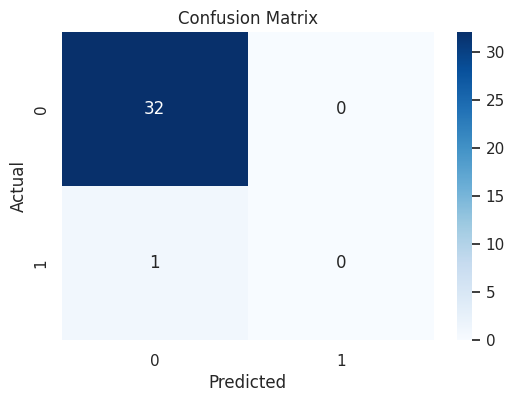

In [19]:
from sklearn.exceptions import NotFittedError

# Create a binary outcome: death_event, 1 if linked_deaths > 0, else 0
if 'linked_deaths' in df.columns:
    # If linked_deaths is NaN, (NaN > 0) is False, so death_event becomes 0.
    df['death_event'] = (df['linked_deaths'] > 0).astype(int)
else:
    print('Column "linked_deaths" not found in the dataset.')
    # If linked_deaths is truly missing, we might need a default for death_event or skip modeling.
    # For now, let's assume it exists or this path isn't hit.

# Define features and target for predicting death_event
features = ['arrests', 'convictions', 'aspirants_affected']
target = 'death_event'

# Ensure all features and target exist in df
required_cols = features + [target]
if not all(col in df.columns for col in required_cols):
    raise ValueError('Missing required columns for predictive modeling.')

# Make a copy of the relevant data for modeling
model_df = df[required_cols].copy()

# Impute missing values in numerical features with 0
# This assumes that NaN for these features means 'no arrests', 'no convictions', 'no aspirants affected'
for col in features:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

# After imputation, ensure no NaNs in the target column (though current death_event logic should prevent this)
model_df.dropna(subset=[target], inplace=True)

print('Number of samples available for modeling after imputation:', model_df.shape[0])

from sklearn.exceptions import DataConversionWarning
import warnings
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

if model_df.shape[0] < 2:
    print('Not enough data points for predictive modeling. Found only', model_df.shape[0], 'sample(s).')
else:
    # Split the data into training and test sets
    X = model_df[features]
    y = model_df[target]
    try:
        # Attempt stratified split first
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
        if X_train.shape[0] == 0 or X_test.shape[0] == 0:
            raise ValueError('The train or test set is empty. Adjust the test_size or check the data distribution.')
    except ValueError as ve:
        # If stratified split fails (e.g., too few samples in one class), try without stratification
        if "The least populated class in y has only 1 member" in str(ve) or "contains only one label" in str(ve):
            print("Warning: Cannot perform stratified split as one class has too few samples. Trying without stratification.")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
            if X_train.shape[0] == 0 or X_test.shape[0] == 0:
                raise ValueError('The train or test set is empty even without stratification.')
        else:
            raise ve # Re-raise if it's a different ValueError

    # Train a Logistic Regression model
    model = LogisticRegression(solver='liblinear') # Use 'liblinear' solver for robustness on small datasets
    model.fit(X_train, y_train)

    # Predict on the test data
    y_pred = model.predict(X_test)

    # Calculate prediction accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Prediction Accuracy: {accuracy:.2f}')

    # Plot the confusion matrix using seaborn heatmap
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## Examining Misclassified Samples

In [20]:
misclassified_indices = y_test[y_test != y_pred].index
misclassified_samples = X_test.loc[misclassified_indices]

print(f"Number of misclassified samples: {len(misclassified_indices)}")
if not misclassified_samples.empty:
    print("Misclassified samples (features):")
    display(misclassified_samples)
    print("Actual labels for misclassified samples:")
    display(y_test.loc[misclassified_indices])
    print("Predicted labels for misclassified samples:")
    display(pd.Series(y_pred[y_test.index.get_indexer(misclassified_indices)], index=misclassified_indices))
else:
    print("No misclassified samples found in the test set.")


Number of misclassified samples: 1
Misclassified samples (features):


,arrests,convictions,aspirants_affected
21,20.0000,0.0000,0.0000


Actual labels for misclassified samples:


,death_event
21,1


Predicted labels for misclassified samples:


,0
21,0


### Visualizing the Target Variable Distribution

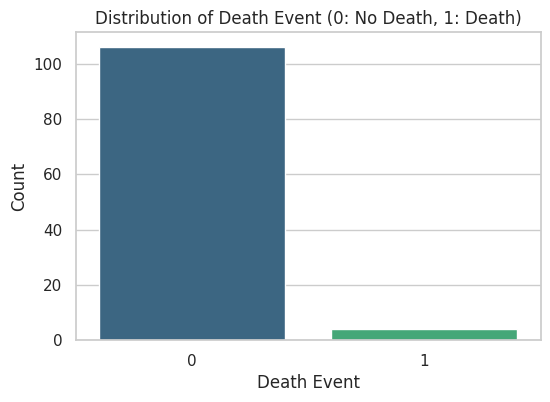

In [21]:
fig = plt.figure(figsize=(6, 4))
sns.countplot(data=model_df, x='death_event', palette='viridis')
plt.title('Distribution of Death Event (0: No Death, 1: Death)')
plt.xlabel('Death Event')
plt.ylabel('Count')
plt.show()


### Visualizing Feature Relationships with Death Event

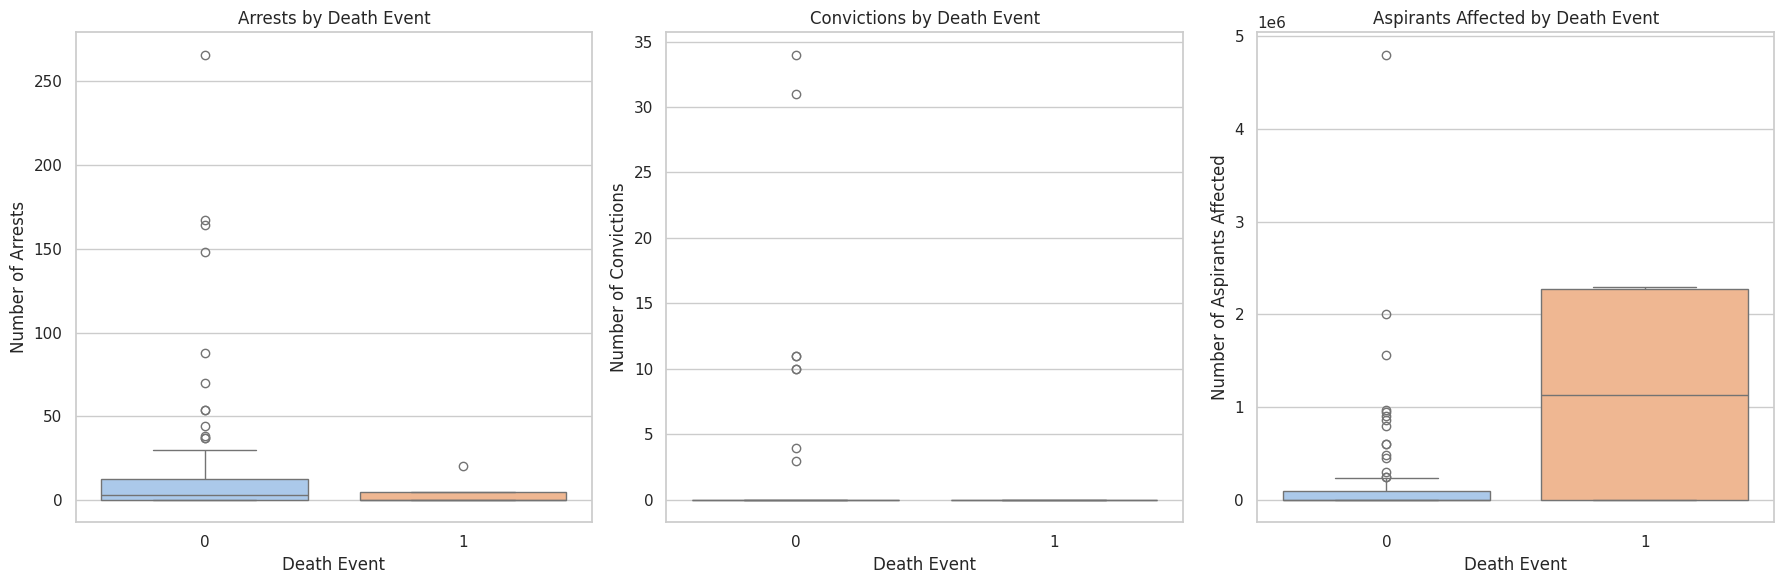

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

sns.boxplot(ax=axes[0], data=model_df, x='death_event', y='arrests', palette='pastel')
axes[0].set_title('Arrests by Death Event')
axes[0].set_xlabel('Death Event')
axes[0].set_ylabel('Number of Arrests')

sns.boxplot(ax=axes[1], data=model_df, x='death_event', y='convictions', palette='pastel')
axes[1].set_title('Convictions by Death Event')
axes[1].set_xlabel('Death Event')
axes[1].set_ylabel('Number of Convictions')

sns.boxplot(ax=axes[2], data=model_df, x='death_event', y='aspirants_affected', palette='pastel')
axes[2].set_title('Aspirants Affected by Death Event')
axes[2].set_xlabel('Death Event')
axes[2].set_ylabel('Number of Aspirants Affected')

plt.tight_layout()
plt.show()


## Helper Functions for Data Analysis and Visualization

These functions are designed to streamline common data processing and visualization tasks, including safe data loading, missingness auditing, column type detection, data cleaning (type coercion, imputation, outlier handling), and various plotting utilities.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed and global configs
np.random.seed(42)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
sns.set_theme(style="whitegrid")

def safe_read_csv(file_path):
    try:
        df_read = pd.read_csv(file_path)
        print(f"[SUCCESS] Successfully loaded data from {file_path}")
        return df_read
    except Exception as e:
        print(f"[ERROR] Failed to load data from {file_path}: {e}")
        return pd.DataFrame()

def audit_missingness(df):
    try:
        null_count = df.isnull().sum()
        null_pct = (null_count / len(df)) * 100
        audit_df = pd.DataFrame({'Missing_Count': null_count, 'Missing_Pct': null_pct})
        return audit_df.sort_values(by='Missing_Pct', ascending=False)
    except Exception as e:
        print(f"[ERROR] audit_missingness failed: {e}")
        return pd.DataFrame()

def detect_column_types(df):
    num_cols = []
    cat_cols = []
    dt_cols = []

    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            dt_cols.append(col)
        elif pd.api.types.is_numeric_dtype(df[col]):
            num_cols.append(col)
        else:
            # Check if it might be datetime
            try:
                converted = pd.to_datetime(df[col].dropna().head(100), errors='coerce')
                if converted.notnull().sum() > 0.8 * len(converted) and len(converted) > 0:
                    dt_cols.append(col)
                    continue
            except Exception:
                pass
            cat_cols.append(col)

    return num_cols, cat_cols, dt_cols


def safe_to_numeric(series):
    try:
        return pd.to_numeric(series, errors='coerce')
    except Exception:
        return series


def safe_to_datetime(series):
    try:
        return pd.to_datetime(series, errors='coerce')
    except Exception:
        return series


def plot_missingness(df):
    try:
        null_series = df.isnull().sum()
        null_series = null_series[null_series > 0].sort_values(ascending=False).head(30)
        if not null_series.empty:
            plt.figure(figsize=(10, 5))
            sns.barplot(x=null_series.values, y=null_series.index, color='skyblue')
            plt.title('Top Missing Values by Column')
            plt.xlabel('Count of Missing Values')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"[ERROR] plot_missingness failed: {e}")


def plot_numeric_histograms(df, num_cols, max_plots=12):
    try:
        cols_to_plot = num_cols[:max_plots]
        if not cols_to_plot:
            return
        n_cols = 3
        n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = np.array(axes).reshape(-1)

        for idx, col in enumerate(cols_to_plot):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='teal')
            axes[idx].set_title(f'Distribution: {col}')

        for idx in range(len(cols_to_plot), len(axes)):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[ERROR] plot_numeric_histograms failed: {e}")


def plot_boxplots(df, num_cols, max_plots=12):
    try:
        cols_to_plot = num_cols[:max_plots]
        if not cols_to_plot:
            return
        n_cols = 3
        n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = np.array(axes).reshape(-1)

        for idx, col in enumerate(cols_to_plot):
            sns.boxplot(y=df[col].dropna(), ax=axes[idx], color='coral')
            axes[idx].set_title(f'Boxplot: {col}')

        for idx in range(len(cols_to_plot), len(axes)):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[ERROR] plot_boxplots failed: {e}")


def plot_categorical_counts(df, cat_cols, max_plots=6):
    try:
        cols_to_plot = cat_cols[:max_plots]
        if not cols_to_plot:
            return
        for col in cols_to_plot:
            plt.figure(figsize=(8, 4))
            top_cats = df[col].astype(str).value_counts().head(10)
            sns.barplot(x=top_cats.values, y=top_cats.index, color='mediumpurple')
            plt.title(f'Top Counts: {col}')
            plt.xlabel('Count')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"[ERROR] plot_categorical_counts failed: {e}")


def plot_correlation_heatmap(df, num_cols):
    try:
        cols_to_corr = num_cols[:50]
        if len(cols_to_corr) > 1:
            corr = df[cols_to_corr].corr(numeric_only=True)
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
            plt.title('Correlation Heatmap')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"[ERROR] plot_correlation_heatmap failed: {e}")


def plot_datetime_counts(df, dt_cols):
    try:
        for col in dt_cols:
            if pd.api.types.is_datetime64_any_dtype(df[col]):
                plt.figure(figsize=(10, 4))
                df[col].dt.year.value_counts().sort_index().plot(kind='bar', color='seagreen')
                plt.title(f'Events by Year ({col})')
                plt.xlabel('Year')
                plt.ylabel('Count')
                plt.tight_layout()
                plt.show()
    except Exception as e:
        print(f"[ERROR] plot_datetime_counts failed: {e}")


## Applying Comprehensive Data Processing and Visualizations

Now, let's use the helper functions to process the data and generate a full suite of visualizations. To avoid impacting the previously trained model, we will create a `df_processed` dataframe by copying and cleaning the original `df` according to the provided ETL steps.

--- ETL / CLEANING Complete. Generating Visualizations ---


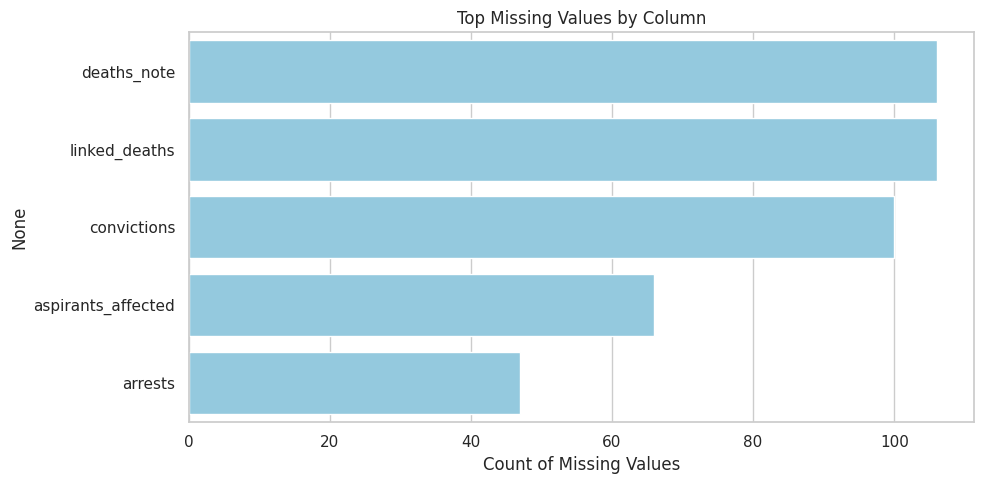

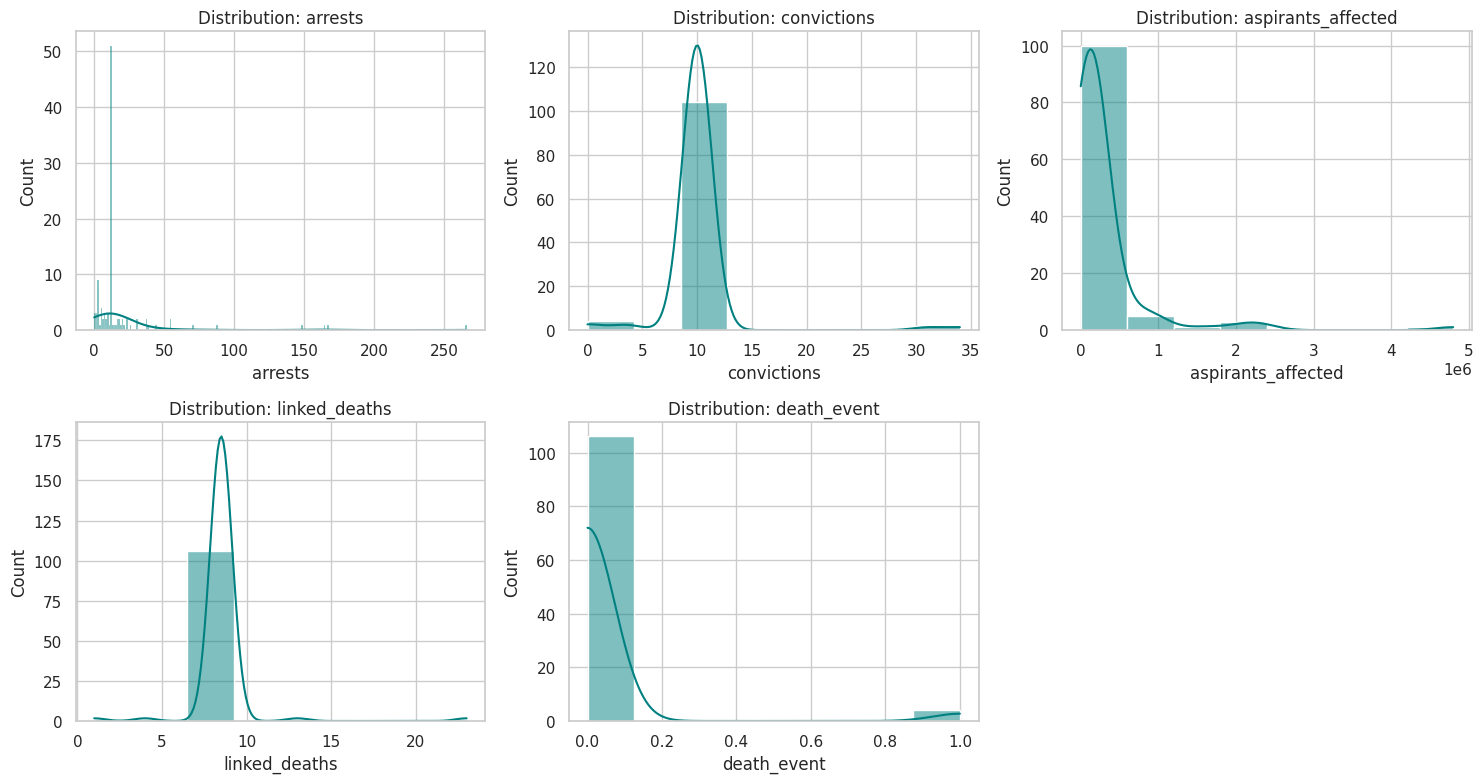

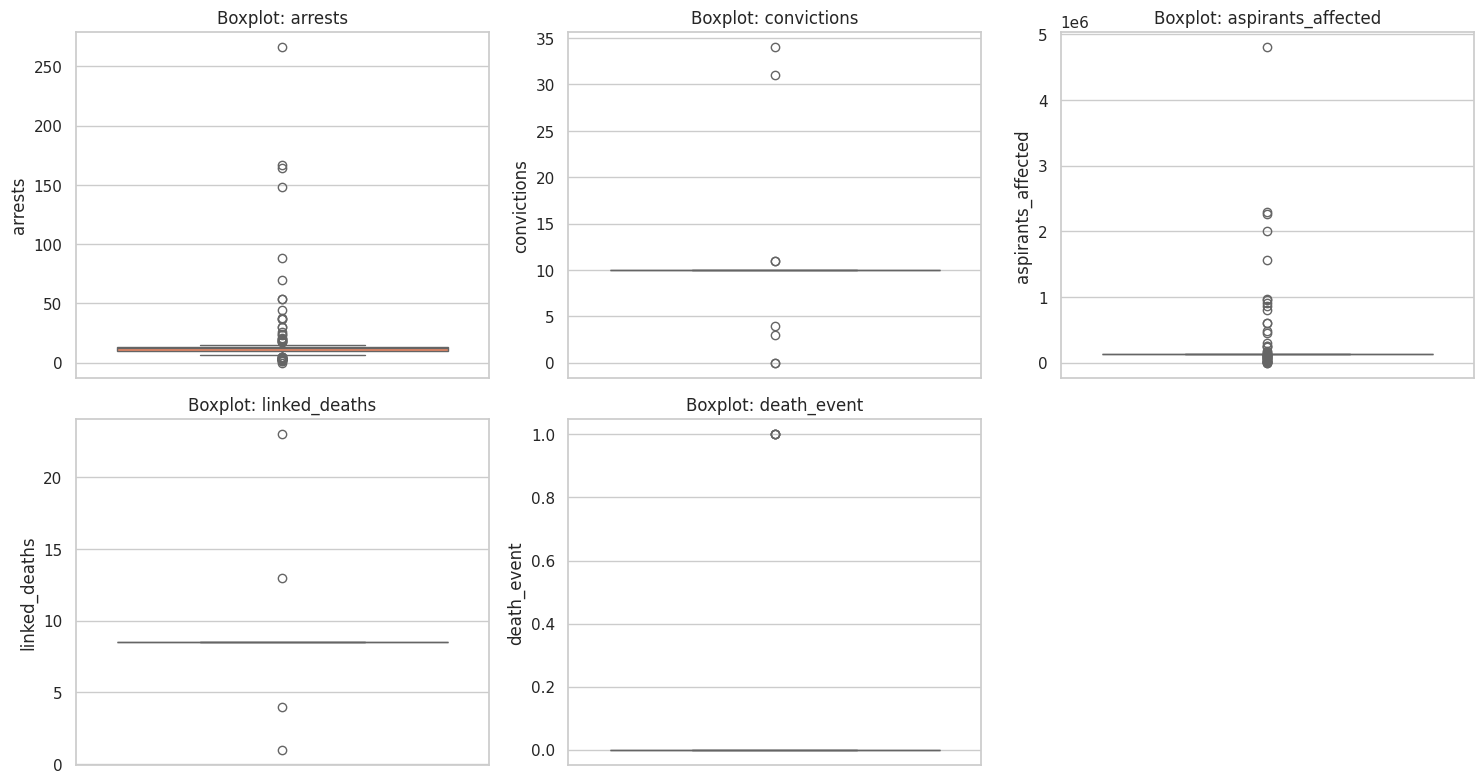

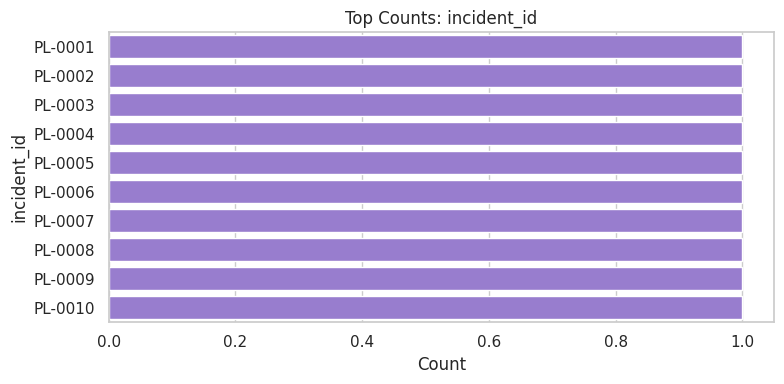

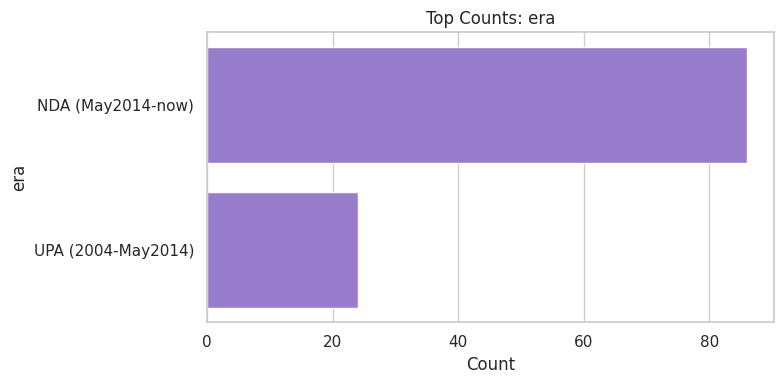

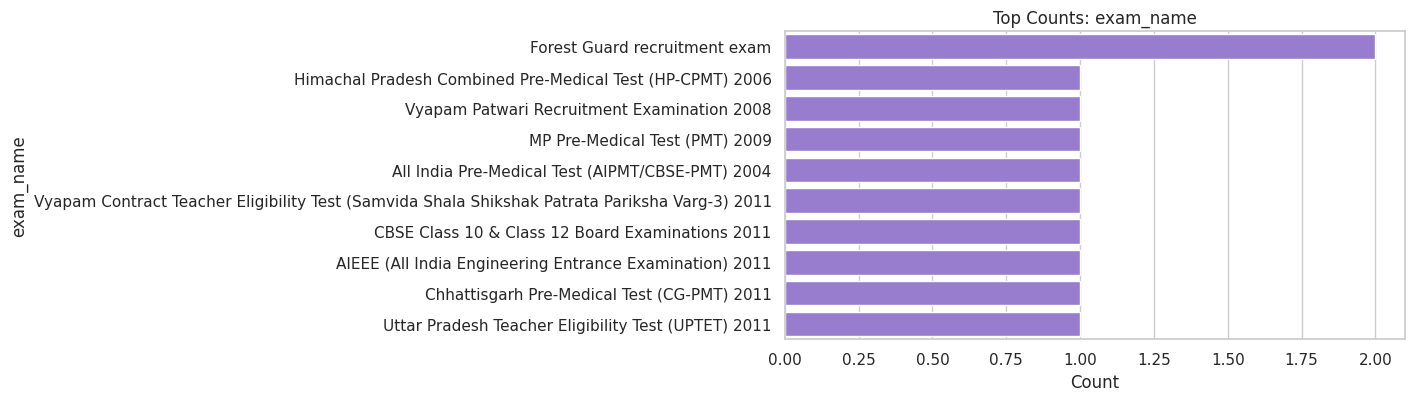

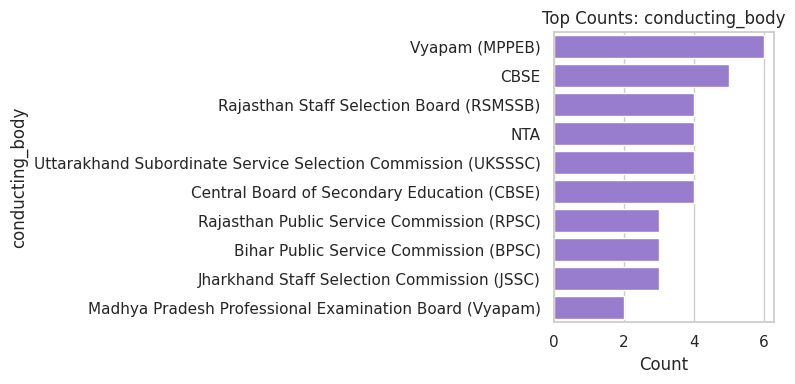

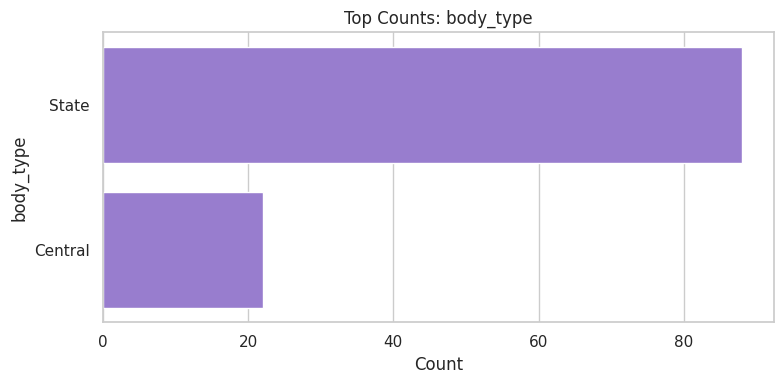

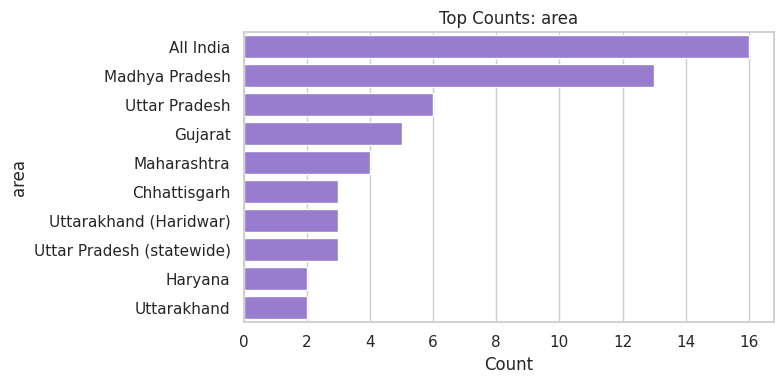

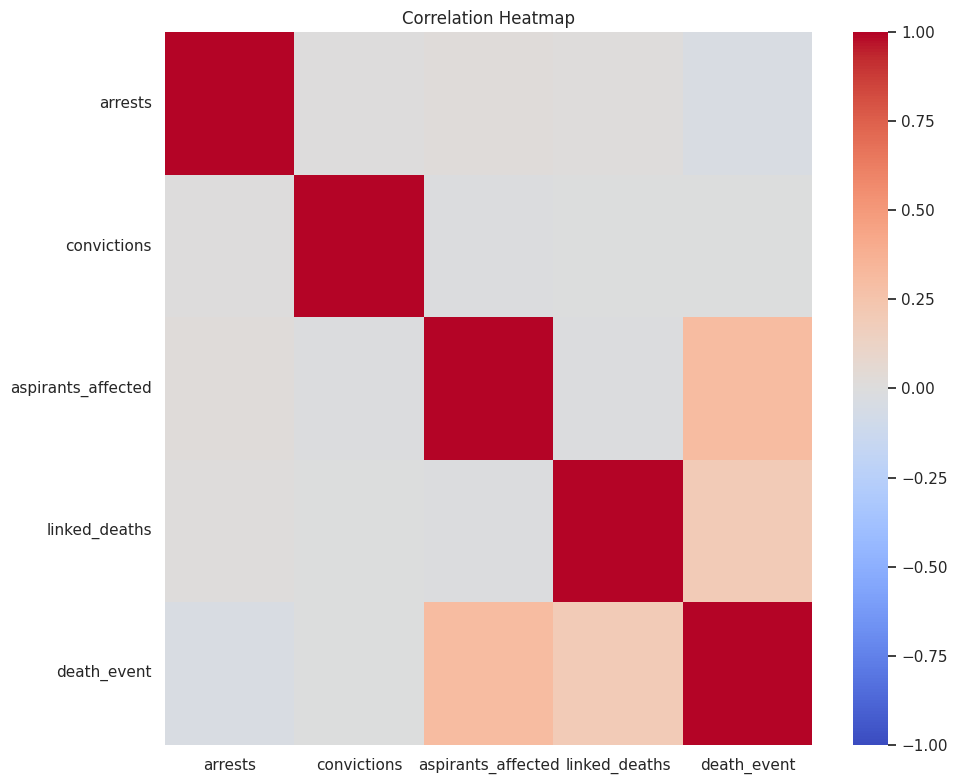

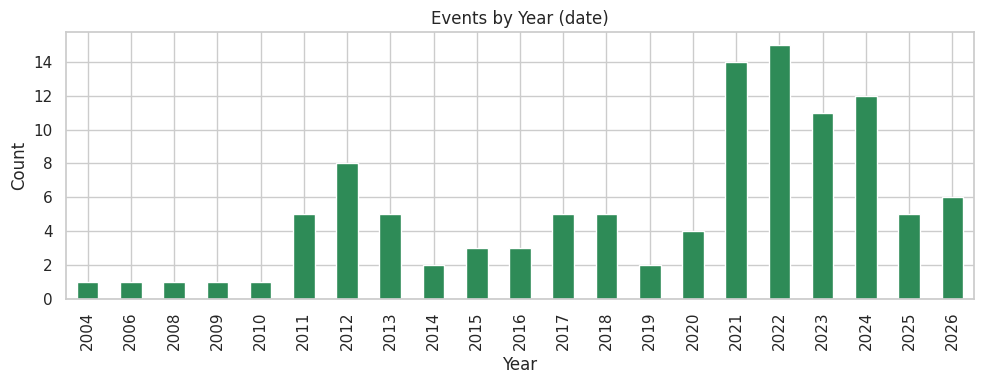

--- All visualizations generated. ---


In [27]:
# --- Data Audit and Cleaning (creating df_processed) ---
df_processed = df.copy()

# Strip whitespace from string columns and unify missing tokens
for c in df_processed.select_dtypes(include='object').columns:
    df_processed[c] = df_processed[c].astype(str).str.strip()
    df_processed[c] = df_processed[c].replace(['', 'nan', 'NaN', 'null', 'NULL', 'None', '?'], np.nan)

# Attempt numeric conversions on object columns where appropriate
for c in df_processed.columns:
    if df_processed[c].dtype == 'object':
        converted = safe_to_numeric(df_processed[c])
        if converted.notnull().sum() > 0.5 * len(df_processed[c].dropna()) and converted.notnull().sum() > 0:
            df_processed[c] = converted

# Safe Datetime conversions
for c in df_processed.columns:
    if 'date' in c.lower() or c in detect_column_types(df_processed)[2]: # Use detect_column_types to get dt_cols for current df_processed
        df_processed[c] = safe_to_datetime(df_processed[c])

# Drop full duplicates
df_processed = df_processed.drop_duplicates()

# Re-detect column types after coercion
num_cols_processed, cat_cols_processed, dt_cols_processed = detect_column_types(df_processed)

# Missing value indicators & Imputation
for c in df_processed.columns:
    if df_processed[c].isnull().sum() > 0:
        df_processed[f"{c}__was_missing"] = df_processed[c].isnull().astype(int)
        if c in num_cols_processed:
            median_val = df_processed[c].median()
            df_processed[c] = df_processed[c].fillna(median_val if pd.notnull(median_val) else 0)
        else:
            df_processed[c] = df_processed[c].fillna("Missing")

# Outlier IQR Detection & Winsorization
for c in num_cols_processed:
    q25 = df_processed[c].quantile(0.25)
    q75 = df_processed[c].quantile(0.75)
    iqr = q75 - q25
    if iqr > 0:
        lower = q25 - 1.5 * iqr
        upper = q75 + 1.5 * iqr
        df_processed[f"{c}__winsor"] = df_processed[c].clip(lower, upper)

print("--- ETL / CLEANING Complete. Generating Visualizations ---")

# --- Generating Visualizations ---
plot_missingness(df) # Plot missingness of the original dataframe
plot_numeric_histograms(df_processed, num_cols_processed)
plot_boxplots(df_processed, num_cols_processed)
plot_categorical_counts(df_processed, cat_cols_processed)
plot_correlation_heatmap(df_processed, num_cols_processed)
plot_datetime_counts(df_processed, dt_cols_processed)

print("--- All visualizations generated. ---")


# Data Handling Architecture: ETL and EDA

ETL (Extract, Transform, Load) and EDA (Exploratory Data Analysis) are two sequential stages in data handling. ETL builds clean, reliable data pipelines from raw sources into a warehouse, while EDA uses charts and stats to find patterns, spot trends, and uncover insights from that ready data.

## 1. The ETL Process
ETL prepares and moves data so it is safe and ready to use:
* **Extract:** Pull raw data from apps, files, or databases.
* **Transform:** Clean messy fields, fix dates, and remove duplicate rows.
* **Load:** Save the clean data into a central data warehouse.

## 2. The EDA Process
EDA explores the data to learn what it means:
* **Inspect:** Check the size, data types, and missing values.
* **Visualize:** Build charts like histograms or scatter plots to see shapes and spreads.
* **Analyze:** Find core trends, groups, or odd data points before building models.
